In [ ]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Handling imbalance
from sklearn.utils import resample

In [4]:
# Load dataset (adjust path)
df = pd.read_csv("online_shoppers_intention.csv")

# Inspect
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


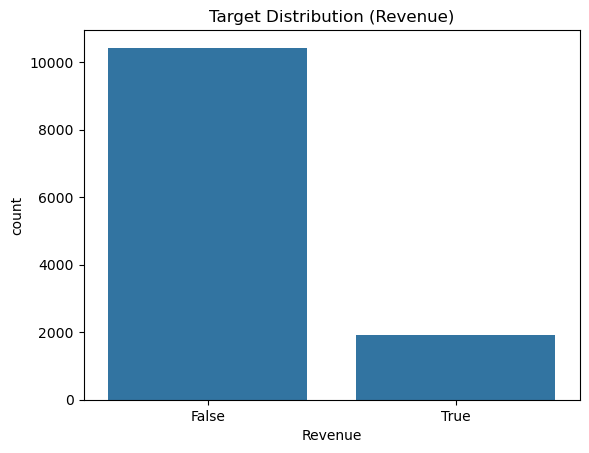

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64


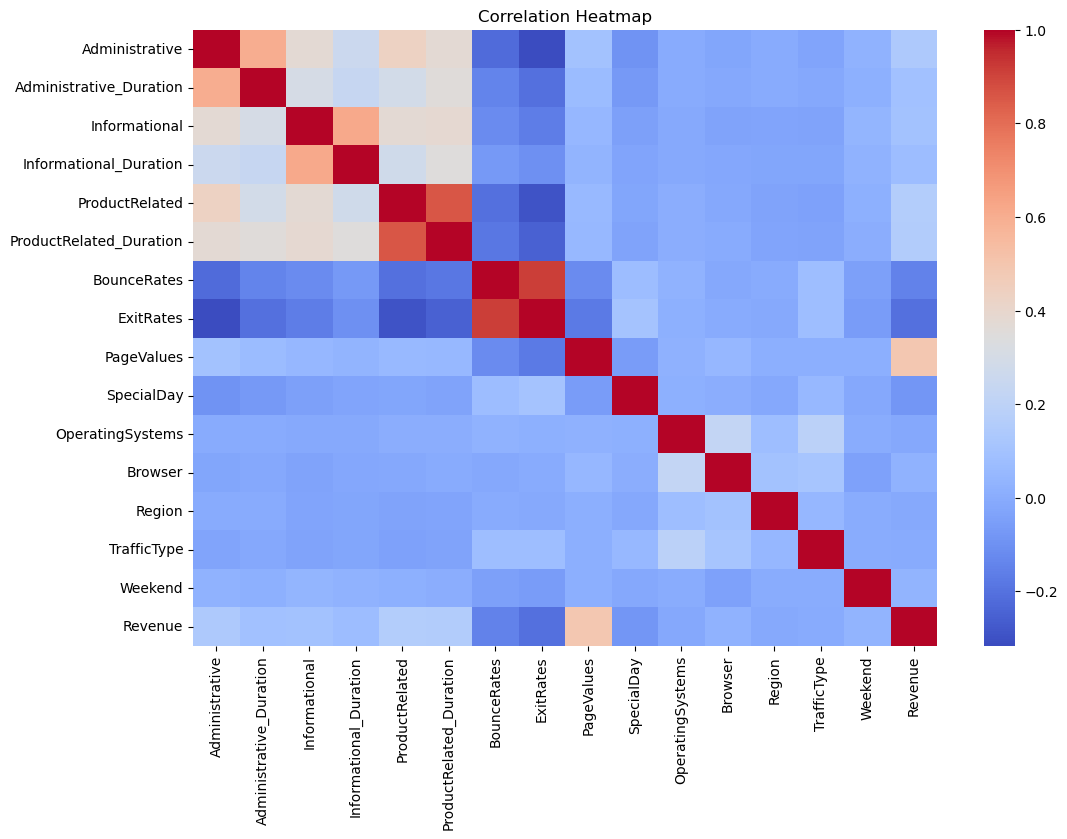

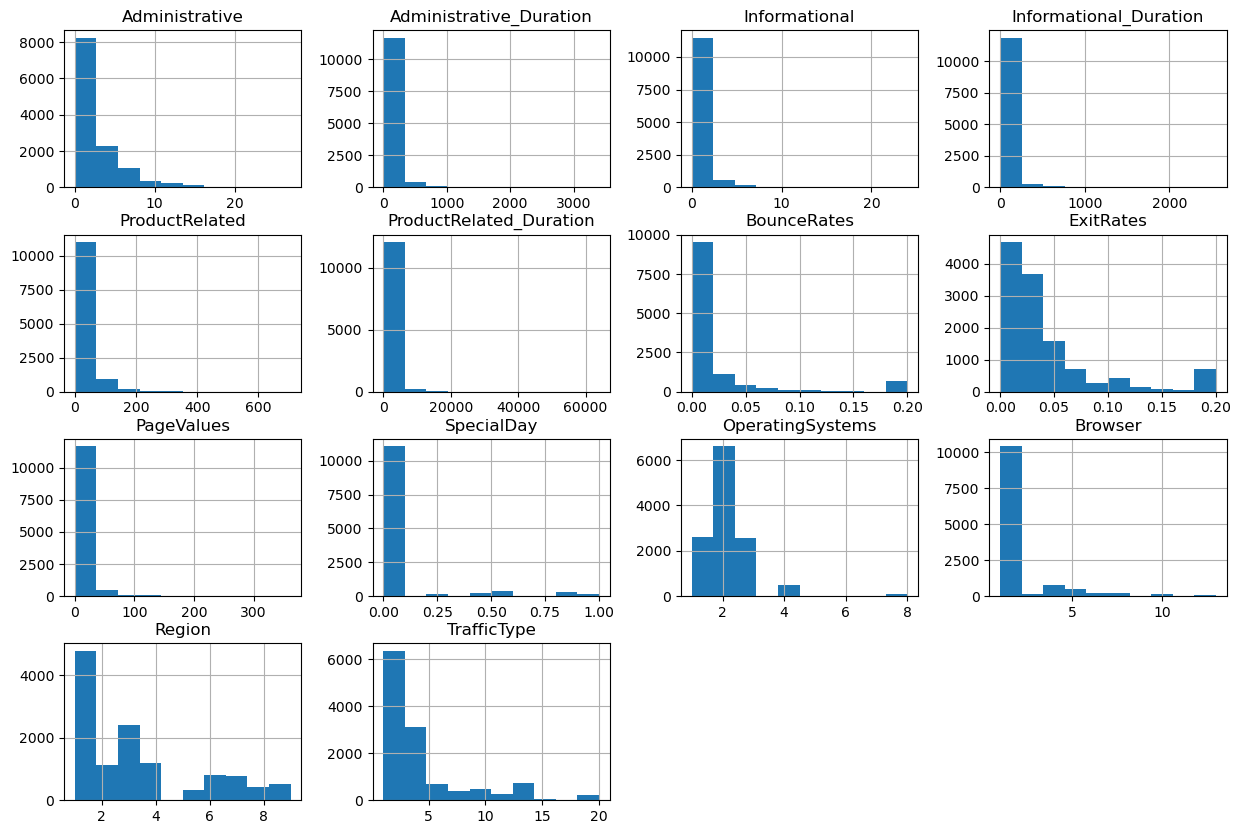

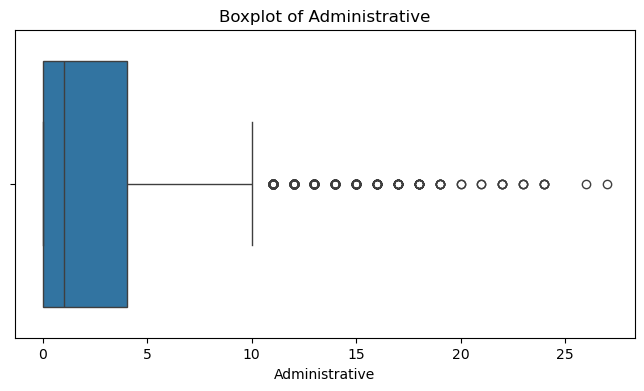

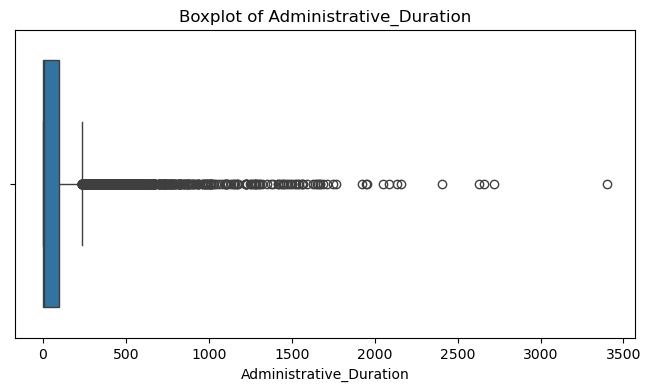

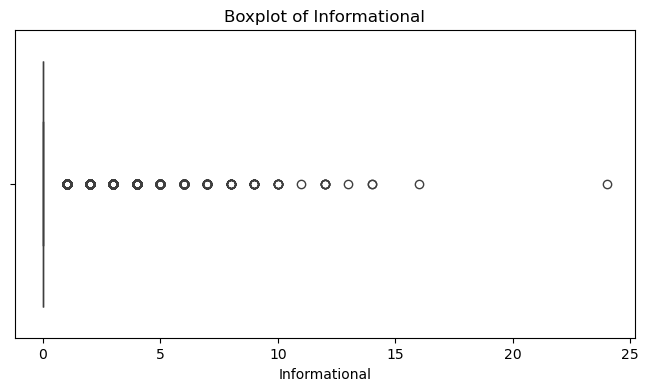

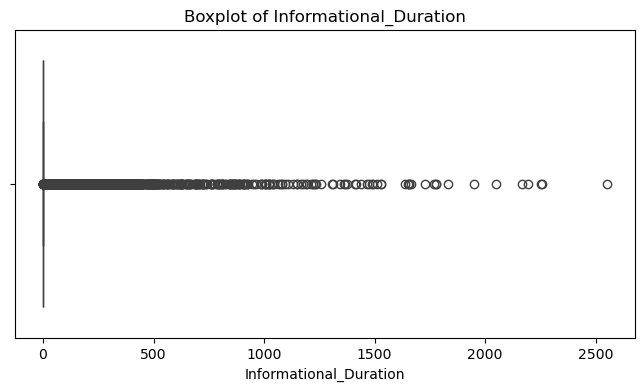

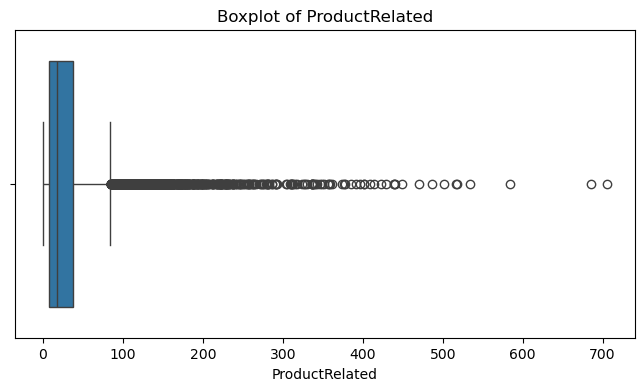

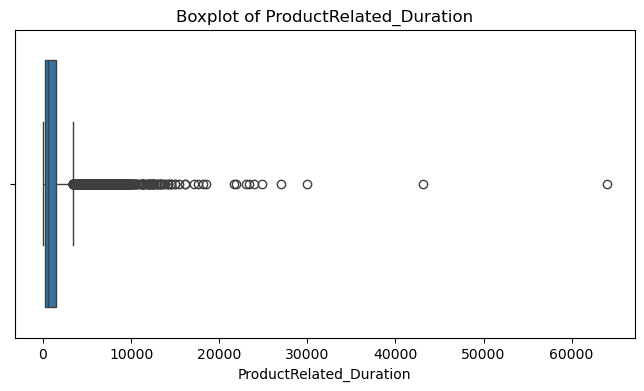

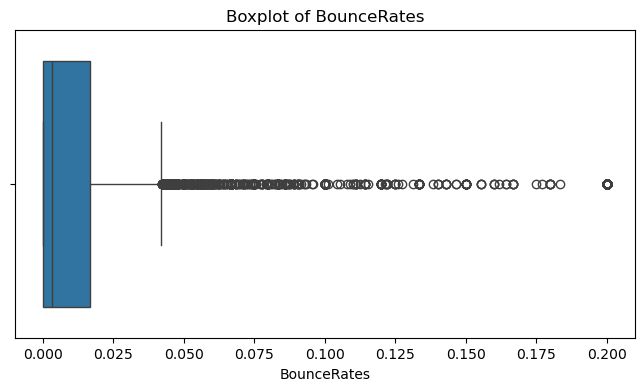

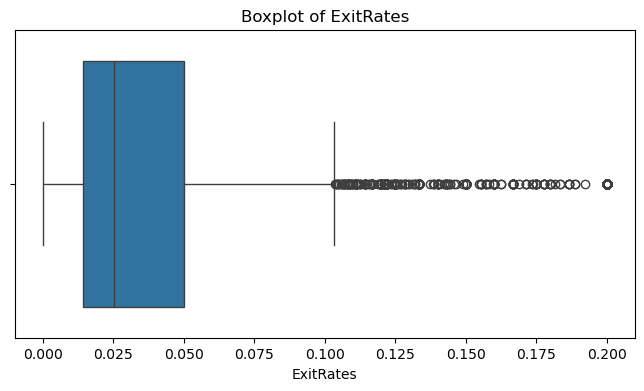

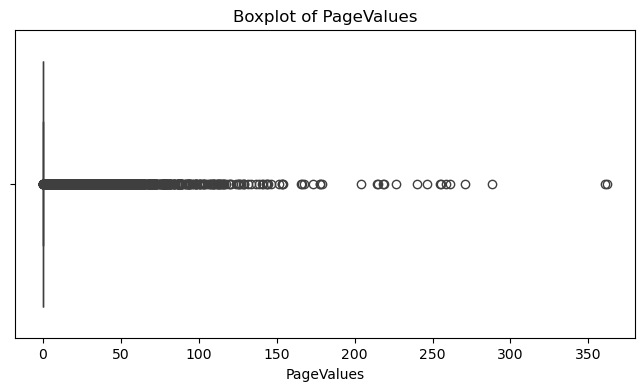

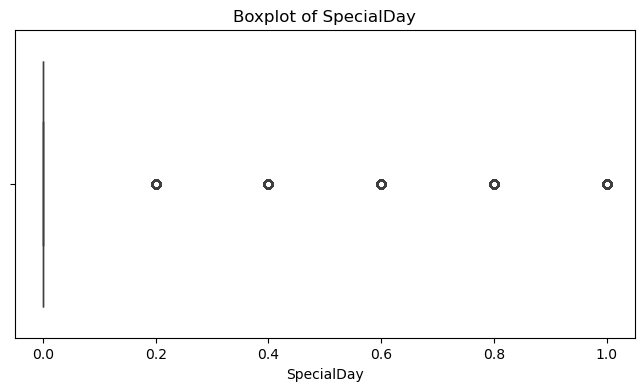

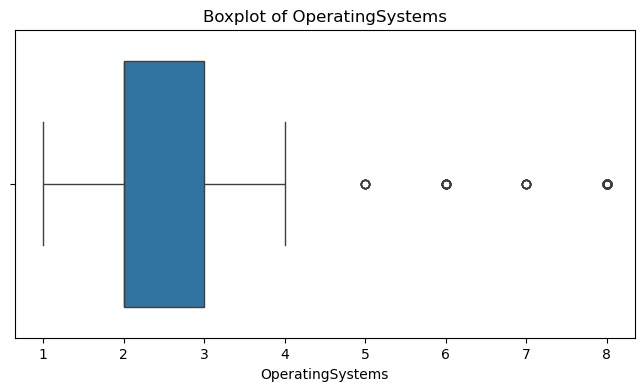

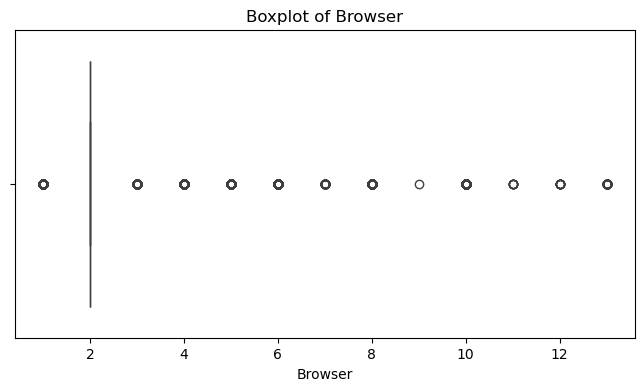

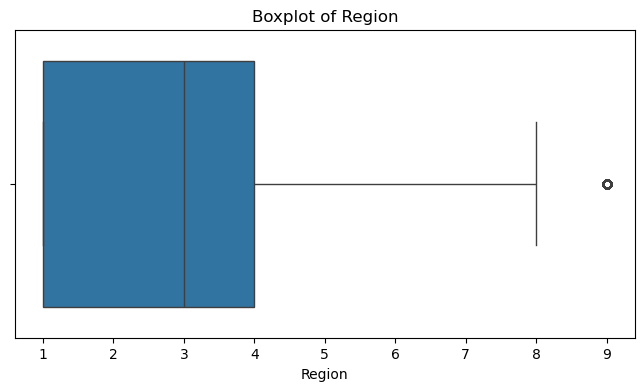

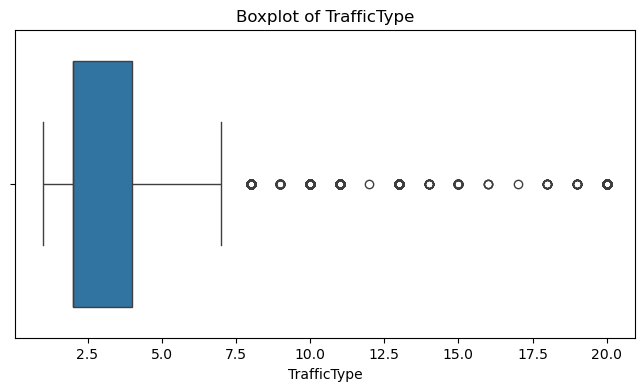

In [ ]:
# EDA

# Target Distribution
sns.countplot(x='Revenue', data=df)
plt.title("Target Distribution (Revenue)")
plt.show()

print(df['Revenue'].value_counts(normalize=True))

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Feature Distributions
df.hist(figsize=(15,10))
plt.show()

# Boxplots for outliers
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [13]:
# Data Preprocessing

# Convert target to binary
df['Revenue'] = df['Revenue'].astype(int)

# Separate Features and Target
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Identify Feature Types
categorical_cols = ['Month', 'VisitorType', 'Weekend']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing Pipelines
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Train/Validation/Test Split
# First split (train + temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split (validation + test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8631, 17)
Validation: (1849, 17)
Test: (1850, 17)


In [ ]:
# Baseline Model 1: Majority Class
majority_class = y_train.mode()[0]
y_pred_baseline = np.full_like(y_val, majority_class)

print("Baseline Accuracy:", accuracy_score(y_val, y_pred_baseline))
print("Baseline F1:", f1_score(y_val, y_pred_baseline))

Baseline Accuracy: 0.8453217955651704
Baseline F1: 0.0


In [15]:
# Baseline Model 2: Logistic Regression
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_val)
y_prob = log_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1563
           1       0.75      0.35      0.47       286

    accuracy                           0.88      1849
   macro avg       0.82      0.66      0.70      1849
weighted avg       0.87      0.88      0.86      1849

ROC-AUC: 0.8890246030361194


In [16]:
# Decision Tree
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5))
])

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1563
           1       0.68      0.50      0.58       286

    accuracy                           0.89      1849
   macro avg       0.80      0.73      0.75      1849
weighted avg       0.88      0.89      0.88      1849



In [17]:
# Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_val)
y_prob = rf_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1563
           1       0.73      0.51      0.60       286

    accuracy                           0.89      1849
   macro avg       0.82      0.74      0.77      1849
weighted avg       0.89      0.89      0.89      1849

ROC-AUC: 0.9144933761056602


In [18]:
# Gradient Boosting
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier())
])

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_val)
y_prob = gb_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1563
           1       0.68      0.55      0.61       286

    accuracy                           0.89      1849
   macro avg       0.80      0.75      0.77      1849
weighted avg       0.88      0.89      0.89      1849

ROC-AUC: 0.9198868949348795


In [19]:
# Suppport Vector Machine
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True))
])

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_val)
y_prob = svm_model.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1563
           1       0.72      0.45      0.55       286

    accuracy                           0.89      1849
   macro avg       0.81      0.71      0.74      1849
weighted avg       0.88      0.89      0.88      1849

ROC-AUC: 0.8605022616538931


In [20]:
# Cross Validation
scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
print("CV ROC-AUC:", scores.mean())

CV ROC-AUC: 0.9310048819444836


In [21]:
# Final Evaluation on Test Set
final_model = rf_model  # choose best model

final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      1564
           1       0.77      0.58      0.66       286

    accuracy                           0.91      1850
   macro avg       0.85      0.77      0.80      1850
weighted avg       0.90      0.91      0.90      1850

Test ROC-AUC: 0.9276308729633538
